## Settings

In [53]:
## auto reload modules
%reload_ext autoreload
%autoreload 2

## Dependencies

In [54]:
## libraries
import sys
import logging
from pathlib import Path
from IPython.display import Markdown, display

## path
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))

## modules
from src.data.builders import (
    load_processed_data, 
    load_falsified_data
)
from src.estimators.factories import load_estimators
from src.evaluators.falsifying import (
    train_falsified_transfer,
    train_falsified_agreement,
    train_falsified_consensus,
    compile_falsified_transfer,
    compile_falsified_agreement,
    compile_falsified_consensus,
    stat_falsified_test,
    stat_falsified_summary,
)
from src.evaluators.tables import main_table
from src.visualizers.visualizing import plot_consensus

## constants
from src.evaluators.metrics import (
    FRONTIER_METRICS,
    CONSENSUS_METRICS
)
from src.evaluators.config import (
    FEAT_X, 
    FEAT_Z, 
    TARGET
)


## Initialization

In [55]:
## reproducibility
N_DECIMALS = 2
N_REPEATS = 30
RANDOM_STATE = 42

## load data and models
_disable = logging.root.manager.disable
logging.disable(logging.INFO)
try:
    data_proc = load_processed_data()
    data_fals = load_falsified_data()
finally:
    logging.disable(_disable)
    models = load_estimators(random_state = RANDOM_STATE)

## view data shape
n_obs, n_feat = data_proc.shape
print(f"Original Data: {n_feat} features, {n_obs} observations")
print("Falsified Data:")
for method, data in data_fals.items():
    n_r, n_c = data.shape
    print(f" - {method}: {n_c} features, {n_r} observations")

## view model surface
n_mods = len(models)
print(f"Learned Models: {n_mods} estimators")

Original Data: 32 features, 25 observations
Falsified Data:
 - random_generate: 32 features, 25 observations
 - target_remap: 32 features, 25 observations
 - vector_generate: 32 features, 25 observations
Learned Models: 9 estimators


## Training

In [56]:
## train falsified transfer
if "results_dict_falsified_transfer" not in globals():
    results_dict_falsified_transfer = train_falsified_transfer(
        data_proc = data_proc,
        data_fals = data_fals,
        models = models,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        group = "domain",
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE
    )

In [57]:
## train falsified structural agreement
if "results_dict_falsified_agreement" not in globals():
    results_dict_falsified_agreement = train_falsified_agreement(
        data_proc = data_proc,
        data_fals = data_fals,
        models = models,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE,
    )

In [58]:
## train falsified pairwise consensus
if "results_dict_falsified_consensus" not in globals():
    results_dict_falsified_consensus = train_falsified_consensus(
        data_proc = data_proc,
        data_fals = data_fals,
        models = models,
        feat_x = FEAT_X,
        feat_z = FEAT_Z,
        target = TARGET,
        n_repeats = N_REPEATS,
        random_state = RANDOM_STATE
    )

## Post-Processing

In [59]:
## compile falsified transfer results
results_falsified_transfer = compile_falsified_transfer(
    results = results_dict_falsified_transfer
)

## compile falsified structural agreement results
results_falsified_agreement = compile_falsified_agreement(
    results = results_dict_falsified_agreement
)

## compile falsified pairwise consensus results
results_falsified_consensus = compile_falsified_consensus(
    results = results_dict_falsified_consensus
)

## Domain Transfer Difference Test
The transfer falsifiability test probes whether deliberately corrupted data reduce EI transfer performance relative to the original empirical baseline. Three falsification types (target remap, random generate, vector generate) are evaluated under frozen and retrained LOGO-CV (domain) protocols and scored by EI per (model x domain). Each falsification method is tested with a paired one-sided Wilcoxon signed-rank statistic comparing original and falsified EI values.

- **$H_0$**: Original EI does not exceed falsified EI ($\Delta EI \le 0$).
- **$H_1$**: Original EI exceeds falsified EI ($\Delta EI > 0$).

Rejecting $H_0$ establishes that EI transfer performance is significantly stronger on original data than on falsified data.

### Falsification Protocol
Target remap corrupts the target association, while random and vector generation corrupt the input feature geometry. Under the frozen protocol, models trained on original data are evaluated directly on falsified inputs. Under the retrain protocol, models are refit on falsified data and compared back to the original baseline.

### Empirical Test Specification
Original and falsified EI values are paired on (model $\times$ domain) within each falsification method and protocol. The paired median shift, rank-biserial effect size, and Holm-adjusted one-sided p-value summarize whether each destructive intervention produces a consistent EI loss.

In [60]:
## wilcoxon signed-rank test for falsified transfer
results_table_transfer = stat_falsified_test(
    results = results_falsified_transfer,
    feat_value = ["ei"],
    feat_pairs = ["model", "group"],
    decimals = N_DECIMALS
)

display(results_table_transfer)

Paired One-Sided Test (Wilcoxon Signed-Rank): n = 45
H₀: Δ EI ≤ 0
H₁: Δ EI > 0
Median Δ EI: Median of paired differences, not the difference of marginal medians
Rank-biserial r: Paired effect size, positive values favor original
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Diff.: Yes if Holm-adj. p < 0.05 and Median Δ > 0
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


Median Δ EI Rank-biserial r One-sided p  \
Falsification Method                                                    
frozen        target remap           0.03            0.42        0.01   
              random generate        0.05            0.75        0.00   
              vector generate        0.03            0.70        0.00   
retrain       target remap           0.05            0.50        0.00   
              random generate        0.04            0.51        0.00   
              vector generate        0.02            0.49        0.00   

                              Holm-adj. p Sig. Diff.  
Falsification Method                                  
frozen        target remap           0.01   **   Yes  
              random generate        0.00  ***   Yes  
              vector generate        0.00  ***   Yes  
retrain       target remap           0.00   **   Yes  
              random generate        0.00   **   Yes  
              vector generate        0.00   **   Yes

In [61]:
## median falsified transfer metrics
transfer_summary = stat_falsified_summary(
    results = results_falsified_transfer,
    metrics = FRONTIER_METRICS,
    decimals = 2
)

display(transfer_summary)

EI [IQR]   VR   MV    MS
Falsification Method                                            
original      original         0.79 [0.75, 0.84]  0.0  0.0  4.54
frozen        target remap     0.75 [0.69, 0.80]  0.2  0.5  5.03
              random generate  0.75 [0.67, 0.82]  0.0  0.0  7.88
              vector generate  0.74 [0.70, 0.81]  0.0  0.0  6.78
retrain       target remap     0.75 [0.69, 0.80]  0.0  0.0  5.60
              random generate  0.78 [0.69, 0.81]  0.0  0.0  5.82
              vector generate  0.75 [0.71, 0.80]  0.0  0.0  5.27

_All three falsification types yield meaningful EI degradation under both the frozen and retrained protocols, with effect sizes comparable across types. Target remap corrupts the target only, while random and vector generation corrupt the input features, yet the resulting EI losses are of similar magnitude. Retraining does not restore original EI performance for any falsification type, and for target remap the retrained contrast is the largest observed shift._

## Structural Agreement Difference Test
The structural agreement falsifiability test probes whether original data produce stronger agreement between model predictions and the observed capacity ordering than falsified data. Each falsification method is tested with a paired one-sided Wilcoxon signed-rank statistic comparing original and falsified CI values.

- **$H_0$**: Original CI does not exceed falsified CI ($\Delta CI \le 0$).
- **$H_1$**: Original CI exceeds falsified CI ($\Delta CI > 0$).

Rejecting $H_0$ establishes that structural agreement is significantly stronger on original data than on falsified data.

### Falsification Protocol
Each falsification method is treated as an independent destructive intervention on the signal used for agreement. Frozen contrasts evaluate whether original model fits retain agreement when scored on falsified data. Retrained contrasts evaluate whether refitting on falsified data restores agreement with the original-data baseline.

### Empirical Test Specification
Original and falsified CI values are paired on (model $\times$ domain) within each falsification method and protocol. The paired median shift, rank-biserial effect size, and Holm-adjusted one-sided p-value summarize whether each intervention produces a consistent loss of structural agreement.

In [62]:
## wilcoxon signed-rank test for falsified structural agreement
results_table_agreement = stat_falsified_test(
    results = results_falsified_agreement,
    feat_value = ["ci"],
    feat_pairs = ["model", "group"],
    decimals = N_DECIMALS
)

display(results_table_agreement)

Paired One-Sided Test (Wilcoxon Signed-Rank): n = 45
H₀: Δ CI ≤ 0
H₁: Δ CI > 0
Median Δ CI: Median of paired differences, not the difference of marginal medians
Rank-biserial r: Paired effect size, positive values favor original
One-sided p: Wilcoxon signed-rank p-value for H₁
Holm-adj. p: Holm-Bonferroni adjusted one-sided p-value
Diff.: Yes if Holm-adj. p < 0.05 and Median Δ > 0
Significance codes reflect Holm-adj. p
*** p < 0.001, ** p < 0.01, * p < 0.05


Median Δ CI Rank-biserial r One-sided p  \
Falsification Method                                                    
frozen        target remap           0.27            0.88        0.00   
              random generate        0.22            0.90        0.00   
              vector generate        0.23            0.90        0.00   
retrain       target remap           0.19            0.86        0.00   
              random generate        0.17            0.72        0.00   
              vector generate        0.25            0.86        0.00   

                              Holm-adj. p Sig. Diff.  
Falsification Method                                  
frozen        target remap           0.00  ***   Yes  
              random generate        0.00  ***   Yes  
              vector generate        0.00  ***   Yes  
retrain       target remap           0.00  ***   Yes  
              random generate        0.00  ***   Yes  
              vector generate        0.00  ***   Yes

In [63]:
## median falsified structural agreement metrics
agreement_summary = stat_falsified_summary(
    results = results_falsified_agreement,
    metrics = CONSENSUS_METRICS,
    decimals = N_DECIMALS
)

display(agreement_summary)

CI [IQR]    ρ   RBO   DCR
Falsification Method                                             
original      original         0.88 [0.68, 0.96]  0.7  0.91  0.84
frozen        target remap     0.56 [0.52, 0.64] -0.3  0.81  0.61
              random generate  0.58 [0.50, 0.74]  0.0  0.81  0.63
              vector generate  0.60 [0.49, 0.68] -0.1  0.81  0.62
retrain       target remap     0.64 [0.55, 0.69]  0.1  0.81  0.61
              random generate  0.65 [0.61, 0.76]  0.2  0.83  0.59
              vector generate  0.58 [0.54, 0.64] -0.1  0.81  0.61

_Every falsification type produces a significant loss of structural agreement under both protocols, with rank-biserial effect sizes at or near the theoretical maximum. Rank correlation with the observed target collapses from positive under the original baseline to near zero or negative under every falsified setting, including target remap. Retraining does not restore structural agreement; several retrained variants remain as far below the original as their frozen counterparts._

## Model Consensus Evaluation
The model consensus evaluation probes whether falsified inputs preserve agreement among independently trained frontiers. Unlike the transfer and structural-agreement sections, this is a descriptive stability analysis rather than a formal falsifiability test. Agreement is computed across all model pairs using the same consensus metrics.

- **Spearman (`ρ`)**: Global rank agreement between paired model frontiers.
- **Rank-Biased Overlap (`RBO`)**: Top-weighted agreement, emphasizing the high-capacity tail.
- **Distance Correlation (`DCR`)**: Nonlinear dependence between paired model frontiers.
- **Composite Index (`CI`)**: Geometric mean of agreement-scaled `ρ`, `RBO`, and `DCR`.

### Falsification Protocol
The evaluation is restricted to the frozen protocol, so model fits remain anchored to the original empirical manifold while falsified inputs are scored. Only falsified-input rows enter the preview and visualization; the original baseline remains available in the compiled results for comparison.

### Reporting Convention
Each falsification method contributes one value per model pair under the frozen protocol. The preview reports medians across all retained frozen falsified pairwise comparisons. Prior to compounding, `ρ` is rescaled from `[-1, 1]` to `[0, 1]` so that negative rank agreement lowers `CI` without collapsing to a single floor. Higher values indicate stronger falsification-stable model consensus.

In [64]:
## consensus preview
round(number = results_falsified_consensus[CONSENSUS_METRICS].median(), ndigits = N_DECIMALS)

rho    0.94
rbo    0.86
dcr    0.94
ci     0.91
dtype: float64

_Frozen falsification reduces model consensus for generated-input interventions, with median `CI` = 0.66 across retained pairwise comparisons. Target remap preserves frozen consensus by construction because input features are unchanged, whereas random and vector generation visibly weaken agreement among fitted frontiers. This pattern indicates that cross-model consensus depends on coherent event-network geometry rather than arbitrary or generated input structure._

## Summary

In [65]:
## manuscript master table for falsification validity
display_table = main_table(
    results_left = results_table_transfer.reset_index(),
    results_right = results_table_agreement.reset_index(),
    index_feat = ["Falsification", "Method"],
    value_feat_left = ["Median Δ EI", "Rank-biserial r", "Sig.", "Diff."],
    value_feat_right = ["Median Δ CI", "Rank-biserial r", "Sig.", "Diff."],
    header_left = "Domain Transfer",
    header_right = "Structural Agreement",
    short_feat_left = ["Δ EI", "r", "Sig.", "Diff."],
    short_feat_right = ["Δ CI", "r", "Sig.", "Diff."],
    row_order = [
        ("frozen",  "target remap"), ("frozen",  "random generate"), ("frozen",  "vector generate"),
        ("retrain", "target remap"), ("retrain", "random generate"), ("retrain", "vector generate"),
    ],
)

display(display_table)
display(
    Markdown(
    "**Δ EI**, **Δ CI**: median signed difference between original and falsified performance, where positive values indicate original data outperforms falsified data. "
    "**r**: rank-biserial correlation effect size. "
    "**Sig.**: Holm-adjusted one-sided Wilcoxon *p* below threshold to test within each outcome "
    "(\\*\\*\\* *p* < 0.001, \\*\\* *p* < 0.01, \\* *p* < 0.05); significance supports the difference hypothesis "
    "H₁: Δ > 0, that original data outperforms falsified data. "
    "**Diff.**: difference supported when Holm-adjusted *p* < 0.05 and median Δ > 0. "
    "Each test is conducted on *n* = 45 (9 models × 5 domains)."
    )
)

Domain Transfer                   \
                                         Δ EI     r Sig. Diff.   
Falsification Method                                             
frozen        target remap               0.03  0.42   **   Yes   
              random generate            0.05  0.75  ***   Yes   
              vector generate            0.03  0.70  ***   Yes   
retrain       target remap               0.05  0.50   **   Yes   
              random generate            0.04  0.51   **   Yes   
              vector generate            0.02  0.49   **   Yes   

                              Structural Agreement                   
                                              Δ CI     r Sig. Diff.  
Falsification Method                                                 
frozen        target remap                    0.27  0.88  ***   Yes  
              random generate                 0.22  0.90  ***   Yes  
              vector generate                 0.23  0.90  ***   Yes  
retrain       target remap                    0.19  0.86  ***   Yes  
              random generate                 0.17  0.72  ***   Yes  
              vector generate                 0.25  0.86  ***   Yes

**Δ EI**, **Δ CI**: median signed difference between original and falsified performance, where positive values indicate original data outperforms falsified data. **r**: rank-biserial correlation effect size. **Sig.**: Holm-adjusted one-sided Wilcoxon *p* below threshold to test within each outcome (\*\*\* *p* < 0.001, \*\* *p* < 0.01, \* *p* < 0.05); significance supports the difference hypothesis H₁: Δ > 0, that original data outperforms falsified data. **Diff.**: difference supported when Holm-adjusted *p* < 0.05 and median Δ > 0. Each test is conducted on *n* = 45 (9 models × 5 domains).

_Both outcomes use paired one-sided Wilcoxon tests on (model, domain) units across frozen and retrained protocols. All six falsification × protocol contrasts show significant domain transfer and structural agreement losses, indicating that each destructive intervention consistently degrades both EI performance and capacity ordering. Effect sizes are uniformly large, and retraining on falsified data does not restore either outcome. Together, these results support the validity of the learned frontier: performance depends on the genuine event-network signal and collapses under deliberate data corruption._


## Visualization

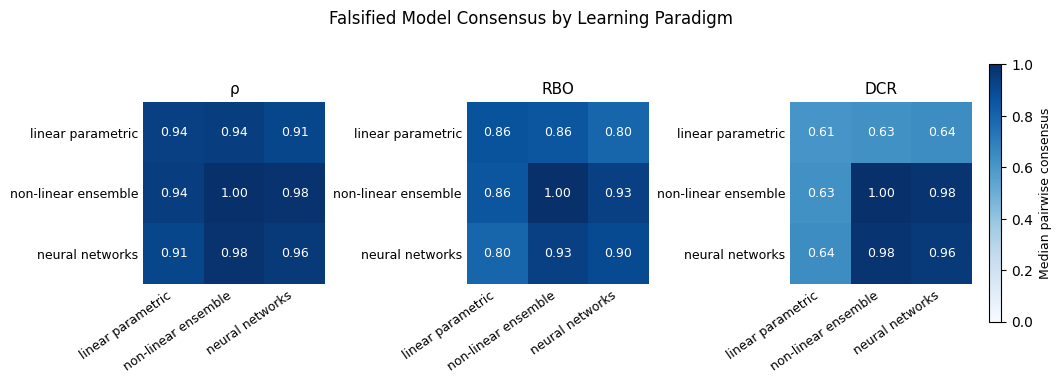

In [66]:
## paradigm-level consensus heatmaps
fig, ax, mat = plot_consensus(
    results = results_falsified_consensus,
    title = "Falsified Model Consensus by Learning Paradigm"
)

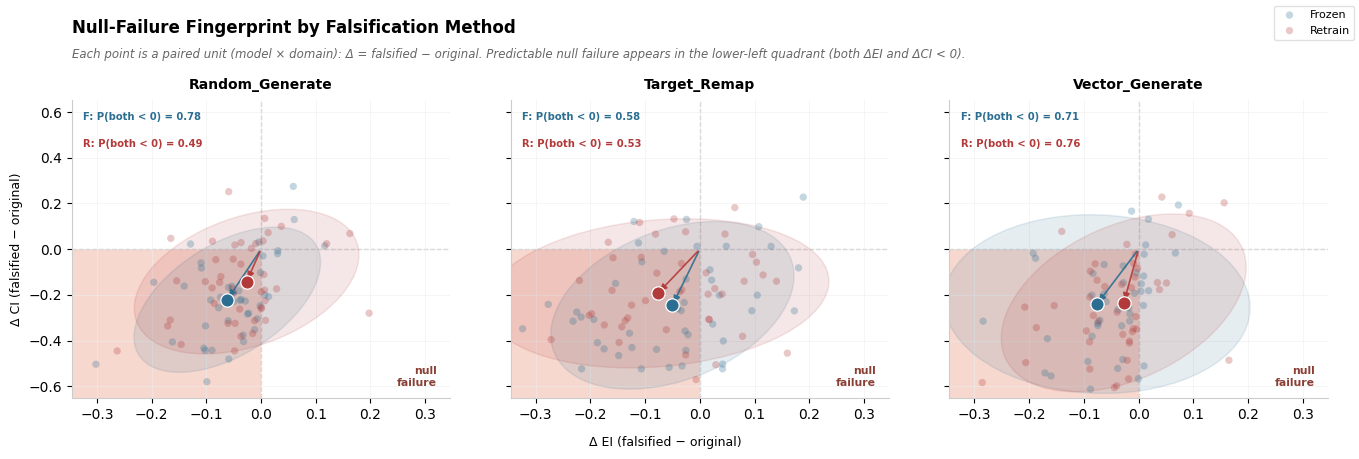

In [67]:
## libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle

## ── pair original vs falsified at unit level (model × domain) ─────────────────
key_cols = ["Falsification", "Method", "model", "group"]

## EI pairs
_ei = (
    results_falsified_transfer
    .loc[:, key_cols + ["condition", "ei"]]
    .pivot_table(index = key_cols, columns = "condition", values = "ei", aggfunc = "median")
    .dropna(subset = ["original", "falsified"])
    .reset_index()
)
_ei["d_ei"] = _ei["falsified"] - _ei["original"]  ## null-failure: negative

## CI pairs
_ci = (
    results_falsified_agreement
    .loc[:, key_cols + ["condition", "ci"]]
    .pivot_table(index = key_cols, columns = "condition", values = "ci", aggfunc = "median")
    .dropna(subset = ["original", "falsified"])
    .reset_index()
)
_ci["d_ci"] = _ci["falsified"] - _ci["original"]  ## null-failure: negative

## merged paired deltas
pairs = _ei[key_cols + ["d_ei"]].merge(_ci[key_cols + ["d_ci"]], on = key_cols, how = "inner")

## stable method order
method_order = ["target remap", "random generate", "vector generate"]
method_order = [m for m in method_order if m in pairs["Method"].unique()] + [
    m for m in sorted(pairs["Method"].unique()) if m not in {"target remap", "random generate", "vector generate"}
]

TRACK_COLORS = {
    "frozen": "#2C6E91",
    "retrain": "#B33A3A",
}

## ── confidence ellipse helper ─────────────────────────────────────────────────
def draw_cov_ellipse(ax, x, y, color, q = 0.80):
    x = np.asarray(x, dtype = float)
    y = np.asarray(y, dtype = float)
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    if not np.all(np.isfinite(cov)):
        return
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 1e-12)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    ## chi2 quantile for 2 dof (0.80): 3.219
    scale = np.sqrt(3.219) if q == 0.80 else 1.0
    width, height = 2.0 * scale * np.sqrt(vals)

    ell = Ellipse(
        xy = (float(np.mean(x)), float(np.mean(y))),
        width = float(width),
        height = float(height),
        angle = float(angle),
        facecolor = color,
        edgecolor = color,
        alpha = 0.12,
        lw = 1.1,
        zorder = 2,
    )
    ax.add_patch(ell)

## ── axis limits ───────────────────────────────────────────────────────────────
lim_x = np.nanpercentile(np.abs(pairs["d_ei"].to_numpy()), 97)
lim_y = np.nanpercentile(np.abs(pairs["d_ci"].to_numpy()), 97)
lim_x = float(max(lim_x, 1e-3) * 1.15)
lim_y = float(max(lim_y, 1e-3) * 1.15)

## ── figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(method_order), figsize = (13.8, 4.8), sharex = True, sharey = True)
if len(method_order) == 1:
    axes = [axes]

fig.subplots_adjust(top = 0.80, bottom = 0.18, left = 0.07, right = 0.98, wspace = 0.16)
fig.text(
    0.07, 0.97,
    "Null-Failure Fingerprint by Falsification Method",
    ha = "left", va = "top", fontsize = 12, fontweight = "semibold",
)
fig.text(
    0.07, 0.91,
    "Each point is a paired unit (model × domain): Δ = falsified − original. "
    "Predictable null failure appears in the lower-left quadrant (both ΔEI and ΔCI < 0).",
    ha = "left", va = "top", fontsize = 8.5, color = "#666", fontstyle = "italic",
)

for ax, method in zip(axes, method_order):
    sub_m = pairs[pairs["Method"] == method].copy()

    ## lower-left failure quadrant
    ax.add_patch(Rectangle((-lim_x, -lim_y), lim_x, lim_y, facecolor = "#F2B8A8", edgecolor = "none", alpha = 0.55, zorder = 0))
    ax.text(
        0.965, 0.035,
        "null\nfailure",
        transform = ax.transAxes,
        ha = "right", va = "bottom", fontsize = 7.8,
        color = "#8A3F34", fontweight = "semibold",
    )

    ## crosshairs
    ax.axhline(0, color = "#BFBFBF", lw = 0.9, ls = "--", zorder = 1)
    ax.axvline(0, color = "#BFBFBF", lw = 0.9, ls = "--", zorder = 1)

    for track in ["frozen", "retrain"]:
        st = sub_m[sub_m["Falsification"] == track].copy()
        if st.empty:
            continue

        c = TRACK_COLORS[track]
        x = st["d_ei"].to_numpy()
        y = st["d_ci"].to_numpy()

        ## paired-unit cloud
        ax.scatter(
            x, y,
            s = 28, color = c, alpha = 0.28,
            edgecolors = "none", zorder = 3,
            label = track.capitalize(),
        )

        ## confidence envelope + centroid vector
        draw_cov_ellipse(ax, x, y, c, q = 0.80)
        mx, my = float(np.mean(x)), float(np.mean(y))
        ax.scatter([mx], [my], s = 92, color = c, edgecolors = "white", linewidths = 0.9, zorder = 5)
        ax.annotate(
            "", xy = (mx, my), xytext = (0, 0),
            arrowprops = dict(arrowstyle = "-|>", color = c, lw = 1.2, alpha = 0.9),
            zorder = 4,
        )

        ## predictable-failure rate
        p_fail = float(np.mean((x < 0) & (y < 0)))
        ax.text(
            0.03,
            0.96 if track == "frozen" else 0.87,
            f"{track[0].upper()}: P(both < 0) = {p_fail:.2f}",
            transform = ax.transAxes,
            ha = "left", va = "top", fontsize = 7.2,
            color = c, fontweight = "semibold",
        )

    ax.set_title(method.title(), fontsize = 10, fontweight = "semibold", pad = 8)
    ax.set_xlim(-lim_x, lim_x)
    ax.set_ylim(-lim_y, lim_y)
    ax.grid(True, color = "#EEEEEE", lw = 0.4, zorder = 0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")

axes[0].set_ylabel("Δ CI (falsified − original)", fontsize = 9)
fig.text(0.5, 0.08, "Δ EI (falsified − original)", ha = "center", fontsize = 9)

## one shared legend
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    by_label = dict(zip(labels, handles))
    fig.legend(by_label.values(), by_label.keys(), loc = "upper right", frameon = True, edgecolor = "#D9D9D9", fontsize = 8)

plt.show()


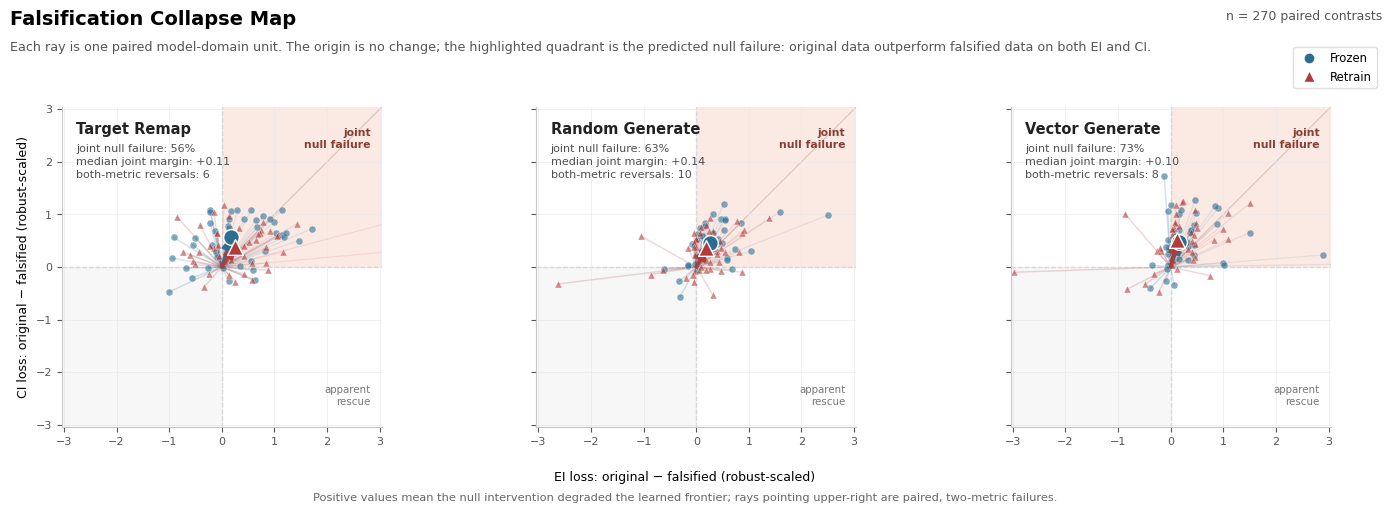

In [68]:
## libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

## pair original and falsified outcomes at the model-domain unit level
key_cols = ["Falsification", "Method", "model", "group"]

ei_pairs = (
    results_falsified_transfer
    .loc[:, key_cols + ["condition", "ei"]]
    .pivot_table(index = key_cols, columns = "condition", values = "ei", aggfunc = "median")
    .dropna(subset = ["original", "falsified"])
    .rename(columns = {"original": "ei_original", "falsified": "ei_falsified"})
    .reset_index()
)

ci_pairs = (
    results_falsified_agreement
    .loc[:, key_cols + ["condition", "ci"]]
    .pivot_table(index = key_cols, columns = "condition", values = "ci", aggfunc = "median")
    .dropna(subset = ["original", "falsified"])
    .rename(columns = {"original": "ci_original", "falsified": "ci_falsified"})
    .reset_index()
)

collapse = ei_pairs.merge(ci_pairs, on = key_cols, how = "inner")
collapse["ei_loss"] = collapse["ei_original"] - collapse["ei_falsified"]
collapse["ci_loss"] = collapse["ci_original"] - collapse["ci_falsified"]

## robust scaling makes EI and CI visually comparable without changing signs
scale_ei = float(np.nanpercentile(np.abs(collapse["ei_loss"]), 90))
scale_ci = float(np.nanpercentile(np.abs(collapse["ci_loss"]), 90))
scale_ei = scale_ei if scale_ei > 0 else 1.0
scale_ci = scale_ci if scale_ci > 0 else 1.0
collapse["ei_loss_scaled"] = collapse["ei_loss"] / scale_ei
collapse["ci_loss_scaled"] = collapse["ci_loss"] / scale_ci
collapse["joint_failure"] = (collapse["ei_loss"] > 0) & (collapse["ci_loss"] > 0)
collapse["joint_reversal"] = (collapse["ei_loss"] < 0) & (collapse["ci_loss"] < 0)

method_priority = {
    "target remap": 0,
    "target_remap": 0,
    "random generate": 1,
    "random_generate": 1,
    "vector generate": 2,
    "vector_generate": 2,
}
method_order = sorted(
    collapse["Method"].dropna().unique(),
    key = lambda value: method_priority.get(value, 99),
)

def method_label(value):
    return str(value).replace("_", " ").title()

track_order = [track for track in ["frozen", "retrain"] if track in set(collapse["Falsification"])]
track_colors = {
    "frozen": "#2C6E91",
    "retrain": "#B33A3A",
}
track_markers = {
    "frozen": "o",
    "retrain": "^",
}

all_scaled_values = np.r_[
    collapse["ei_loss_scaled"].to_numpy(dtype = float),
    collapse["ci_loss_scaled"].to_numpy(dtype = float),
]
axis_limit = float(np.nanpercentile(np.abs(all_scaled_values), 99) * 1.18)
axis_limit = max(axis_limit, 1.35)

## figure
fig, axes = plt.subplots(
    nrows = 1,
    ncols = len(method_order),
    figsize = (15.0, 5.25),
    sharex = True,
    sharey = True,
)
if len(method_order) == 1:
    axes = np.asarray([axes])

fig.subplots_adjust(top = 0.78, bottom = 0.17, left = 0.07, right = 0.985, wspace = 0.12)
fig.text(
    0.07, 0.965,
    "Falsification Collapse Map",
    ha = "left", va = "top", fontsize = 14, fontweight = "semibold",
)
fig.text(
    0.07, 0.905,
    "Each ray is one paired model-domain unit. The origin is no change; the highlighted quadrant is the predicted null failure: "
    "original data outperform falsified data on both EI and CI.",
    ha = "left", va = "top", fontsize = 9.2, color = "#555555",
)
fig.text(
    0.985, 0.965,
    f"n = {len(collapse)} paired contrasts",
    ha = "right", va = "top", fontsize = 9, color = "#555555",
)

for axis, method in zip(axes, method_order):
    method_data = collapse[collapse["Method"] == method].copy()

    axis.add_patch(Rectangle((0, 0), axis_limit, axis_limit, facecolor = "#F2B8A8", edgecolor = "none", alpha = 0.30, zorder = 0))
    axis.add_patch(Rectangle((-axis_limit, -axis_limit), axis_limit, axis_limit, facecolor = "#F1F1F1", edgecolor = "none", alpha = 0.55, zorder = 0))
    axis.axhline(0, color = "#BDBDBD", lw = 0.9, ls = "--", zorder = 1)
    axis.axvline(0, color = "#BDBDBD", lw = 0.9, ls = "--", zorder = 1)
    axis.plot([0, axis_limit], [0, axis_limit], color = "#8A5A4F", lw = 0.8, alpha = 0.28, zorder = 1)

    for track in track_order:
        track_data = method_data[method_data["Falsification"] == track].copy()
        if track_data.empty:
            continue

        color = track_colors.get(track, "#666666")
        marker = track_markers.get(track, "o")
        ei_scaled = track_data["ei_loss_scaled"].to_numpy(dtype = float)
        ci_scaled = track_data["ci_loss_scaled"].to_numpy(dtype = float)

        for ei_value, ci_value in zip(ei_scaled, ci_scaled):
            is_failure = (ei_value > 0) and (ci_value > 0)
            axis.plot(
                [0, ei_value], [0, ci_value],
                color = color,
                alpha = 0.11 if is_failure else 0.20,
                lw = 0.90 if is_failure else 1.05,
                zorder = 2,
            )

        axis.scatter(
            ei_scaled, ci_scaled,
            s = 25, marker = marker, facecolor = color,
            edgecolor = "white", linewidth = 0.35, alpha = 0.58, zorder = 3,
        )

        median_ei = float(np.nanmedian(ei_scaled))
        median_ci = float(np.nanmedian(ci_scaled))
        axis.annotate(
            "",
            xy = (median_ei, median_ci),
            xytext = (0, 0),
            arrowprops = dict(arrowstyle = "-|>", color = color, lw = 2.4, shrinkA = 0, shrinkB = 0, mutation_scale = 15, alpha = 0.96),
            zorder = 5,
        )
        axis.scatter([median_ei], [median_ci], s = 128, marker = marker, facecolor = color, edgecolor = "white", linewidth = 1.0, zorder = 6)

    joint_failure_rate = float(method_data["joint_failure"].mean())
    joint_reversal_count = int(method_data["joint_reversal"].sum())
    median_margin = float(np.nanmedian(np.minimum(method_data["ei_loss_scaled"], method_data["ci_loss_scaled"])))

    axis.text(0.045, 0.955, f"{method_label(method)}", transform = axis.transAxes, ha = "left", va = "top", fontsize = 10.5, fontweight = "semibold", color = "#222222")
    axis.text(
        0.045, 0.885,
        f"joint null failure: {joint_failure_rate:.0%}\nmedian joint margin: {median_margin:+.2f}\nboth-metric reversals: {joint_reversal_count}",
        transform = axis.transAxes,
        ha = "left", va = "top", fontsize = 8.0, color = "#4F4F4F", linespacing = 1.35,
    )
    axis.text(0.965, 0.065, "apparent\nrescue", transform = axis.transAxes, ha = "right", va = "bottom", fontsize = 7.4, color = "#777777")
    axis.text(0.965, 0.935, "joint\nnull failure", transform = axis.transAxes, ha = "right", va = "top", fontsize = 7.8, color = "#8A3F34", fontweight = "semibold")

    axis.set_xlim(-axis_limit, axis_limit)
    axis.set_ylim(-axis_limit, axis_limit)
    axis.set_aspect("equal", adjustable = "box")
    axis.grid(True, color = "#E8E8E8", lw = 0.45, zorder = 0)
    axis.spines[["top", "right"]].set_visible(False)
    axis.spines["left"].set_color("#C8C8C8")
    axis.spines["bottom"].set_color("#C8C8C8")
    axis.tick_params(axis = "both", labelsize = 8, colors = "#555555")

axes[0].set_ylabel("CI loss: original − falsified (robust-scaled)", fontsize = 9)
fig.text(0.52, 0.075, "EI loss: original − falsified (robust-scaled)", ha = "center", va = "center", fontsize = 9)
fig.text(
    0.52, 0.035,
    "Positive values mean the null intervention degraded the learned frontier; rays pointing upper-right are paired, two-metric failures.",
    ha = "center", va = "center", fontsize = 8.2, color = "#666666",
)

legend_handles = [
    Line2D(
        [0], [0],
        marker = track_markers.get(track, "o"),
        color = "none",
        markerfacecolor = track_colors.get(track, "#666666"),
        markeredgecolor = "white",
        markersize = 8,
        label = track.capitalize(),
    )
    for track in track_order
]
fig.legend(handles = legend_handles, loc = "upper right", bbox_to_anchor = (0.985, 0.905), frameon = True, edgecolor = "#D7D7D7", fontsize = 8.4)

plt.show()